In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

ROOT = Path.cwd().parent
DATA_PATH = ROOT / "data" / "processed" / "hotel_bookings_clean.csv"
VISUALS_DIR = ROOT / "visuals"

(86637, 42)
Overall cancellation rate (%): 27.7


In [8]:
# Step 1: calculate the cancellation rate (%) for each hote
rate = df.groupby("hotel")["is_canceled"].mean()*100
print(rate.round(1))
print(df.groupby("hotel")["is_canceled"].agg(["sum","count"]))


hotel
City Hotel      30.2
Resort Hotel    23.7
Name: is_canceled, dtype: float64
                sum  count
hotel                     
City Hotel    16021  53042
Resort Hotel   7964  33595


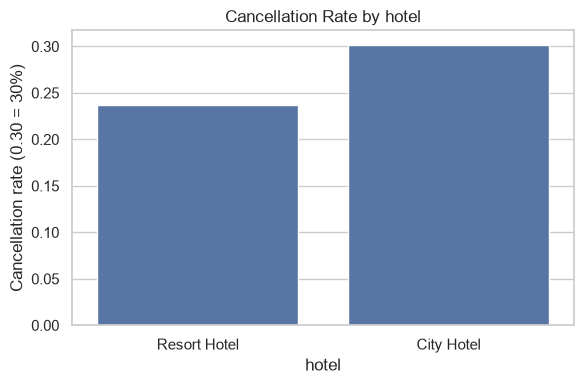

In [12]:
# Step 2: draw the bar chart


plt.figure(figsize=(6, 4))
sns.barplot(x="hotel", y="is_canceled", data=df, errorbar=None)
plt.title("Cancellation Rate by hotel")
plt.xlabel("hotel")
plt.ylabel("Cancellation rate (0.30 = 30%)")
plt.tight_layout()
plt.show()

lead_time_group
0-7d         8.5
8-30d       25.5
31-90d      32.1
91-180d     35.1
181-365d    39.8
365d+       41.0
Name: is_canceled, dtype: float64


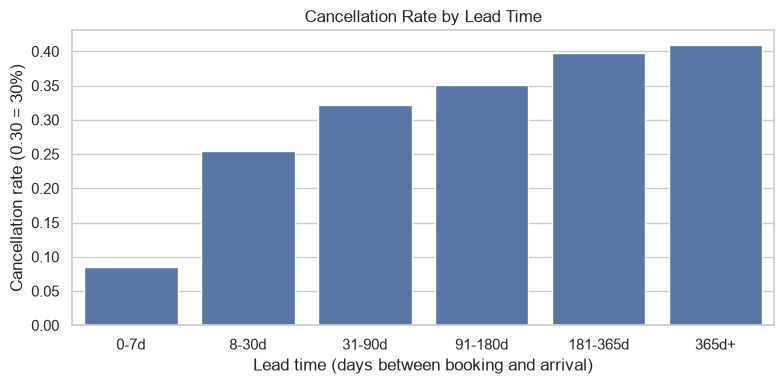

In [16]:
# Step 1: print the cancellation rate (%) in the correct order
rate = df.groupby("lead_time_group")["is_canceled"].mean().reindex(lead_order) * 100
print(rate.round(1))

# Step 2: draw the bar chart
plt.figure(figsize=(8, 4))
sns.barplot(x="lead_time_group", y="is_canceled", data=df, order=lead_order, errorbar=None)
plt.title("Cancellation Rate by Lead Time")
plt.xlabel("Lead time (days between booking and arrival)")
plt.ylabel("Cancellation rate (0.30 = 30%)")
plt.tight_layout()
plt.savefig(VISUALS_DIR / "07_cancellation_by_lead_time.png")
plt.show()

### Insights

1. **Early bookings are more likely to be cancelled.**  
   Last-minute bookings have a cancellation rate of only **8.5%**, while bookings made more than **6 months in advance have a cancellation rate of about 40%**. So, **the earlier someone books, the higher the chance they will cancel**.

2. **Last-minute bookings are more reliable.**  
   Only **8.5% of last-minute bookings are cancelled**. These guests are probably more certain about their travel plans.

3. **Early bookings are risky for the hotel.**  
   Bookings made **more than 90 days in advance have a 35–41% cancellation rate**. This is much higher than the overall average of **27.7%** because people's plans can change over time.

4. **Be careful with the 365+ day group.**  
   This group has a **41% cancellation rate**, but it contains only **561 bookings**. Because the number of bookings is small, this percentage may be less reliable.

5. **This could explain some of the City vs Resort difference.**  
   If **City Hotel guests book earlier**, this could be one reason why City Hotel has a higher cancellation rate. However, this is only a **possible explanation**, and we need to check the data before making a conclusion.

### Main takeaway

**The earlier guests book, the more likely they are to cancel. Last-minute bookings are much more reliable.**

               mean  count
deposit_type              
No Deposit    0.269  85493
Non Refund    0.947   1037
Refundable    0.243    107
                 mean  count
market_segment              
Online TA       0.355  51285
Groups          0.272   4891
Aviation        0.198    222
Offline TA/TO   0.149  13748
Direct          0.149  11652
Corporate       0.122   4155
Complementary   0.122    682


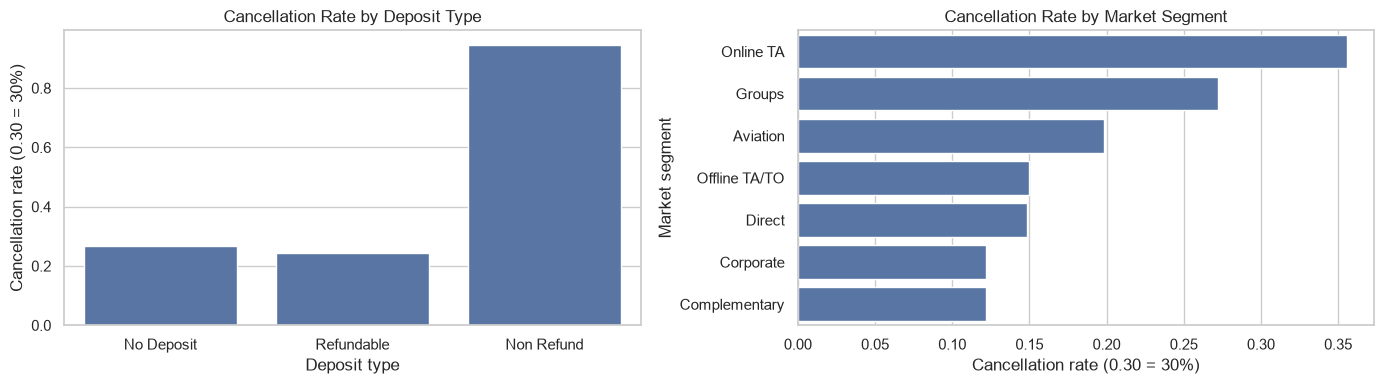

In [17]:
# Step 1: remove the tiny "Undefined" segment (only 2 bookings) and sort the segments
seg = df[df["market_segment"] != "Undefined"]
seg_order = seg.groupby("market_segment")["is_canceled"].mean().sort_values(ascending=False).index

# Step 2: print the numbers (rate and number of bookings)
print(df.groupby("deposit_type")["is_canceled"].agg(["mean", "count"]).round(3))
print(seg.groupby("market_segment")["is_canceled"].agg(["mean", "count"]).sort_values("mean", ascending=False).round(3))

# Step 3: make an empty canvas
plt.figure(figsize=(14, 4))

# Step 4: left chart - deposit type
plt.subplot(1, 2, 1)
sns.barplot(x="deposit_type", y="is_canceled", data=df, errorbar=None)
plt.title("Cancellation Rate by Deposit Type")
plt.xlabel("Deposit type")
plt.ylabel("Cancellation rate (0.30 = 30%)")

# Step 5: right chart - market segment (horizontal, sorted)
plt.subplot(1, 2, 2)
sns.barplot(y="market_segment", x="is_canceled", data=seg, order=seg_order, errorbar=None)
plt.title("Cancellation Rate by Market Segment")
plt.xlabel("Cancellation rate (0.30 = 30%)")
plt.ylabel("Market segment")

# Step 6: tidy up, save, and show
plt.tight_layout()
plt.savefig(VISUALS_DIR / "08_cancellation_by_deposit_and_segment.png")
plt.show()

### Insights

1. **Non-Refundable bookings have a surprising cancellation rate.**  
   About **94.7% of Non-Refundable bookings were cancelled**. This is surprising because we would normally expect guests who cannot get a refund to be more likely to arrive.

   We **cannot say that deposits caused the cancellations**. There may be another reason, such as the booking channel or the way the booking was made. The available data does not tell us the exact reason.

2. **Online travel agents have the most cancellations.**  
   Bookings from websites such as **Booking.com and Expedia** have a **35.5% cancellation rate**. This is much higher than **Direct bookings (14.9%)** and **Corporate bookings (12.2%)**.

   Online travel agents also make up **59% of all bookings**, so they have a big impact on the hotel's overall cancellation rate.

3. **Direct and Corporate bookings are more reliable.**  
   Guests who book **directly with the hotel, through a company, or through offline channels** have cancellation rates of around **12–15%**. This means these bookings are more likely to result in an actual stay.

4. **Be careful with the smaller groups.**  
   There are **85,493 No Deposit bookings**, compared with only **1,037 Non-Refundable** and **107 Refundable bookings**.

   Because the Refundable group contains only **107 bookings**, its **24.3% cancellation rate may not be very reliable**.

### Main takeaway

**Online travel agents are the biggest cancellation problem, while Direct and Corporate bookings are much more reliable. The very high Non-Refundable cancellation rate is unusual and needs further investigation.**

               count   mean   std  min   25%    50%    75%    max
is_canceled                                                      
0            62652.0  103.1  50.5  0.0  68.5   95.0  130.0  510.0
1            23985.0  117.7  51.8  0.0  81.0  109.8  144.0  450.0
               mean  count
room_changed              
0             0.316  73977
1             0.048  12660


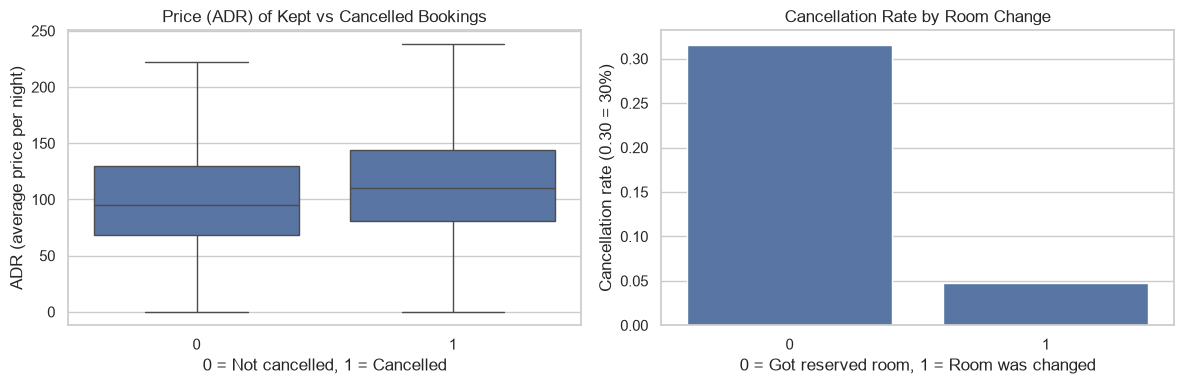

In [18]:
# Step 1: print the numbers
print(df.groupby("is_canceled")["adr"].describe().round(1))
print(df.groupby("room_changed")["is_canceled"].agg(["mean", "count"]).round(3))

# Step 2: make an empty canvas
plt.figure(figsize=(12, 4))

# Step 3: left chart - price of kept vs cancelled bookings (boxplot)
plt.subplot(1, 2, 1)
sns.boxplot(x="is_canceled", y="adr", data=df, showfliers=False)
plt.title("Price (ADR) of Kept vs Cancelled Bookings")
plt.xlabel("0 = Not cancelled, 1 = Cancelled")
plt.ylabel("ADR (average price per night)")

# Step 4: right chart - room changed
plt.subplot(1, 2, 2)
sns.barplot(x="room_changed", y="is_canceled", data=df, errorbar=None)
plt.title("Cancellation Rate by Room Change")
plt.xlabel("0 = Got reserved room, 1 = Room was changed")
plt.ylabel("Cancellation rate (0.30 = 30%)")

# Step 5: tidy up, save, and show
plt.tight_layout()
plt.savefig(VISUALS_DIR / "09_cancellation_by_price_and_room_change.png")
plt.show()

### Insights

1. **Cancelled bookings are usually more expensive.**  
   The median price of a cancelled booking is about **€110 per night**, compared with **€95 per night** for bookings that were not cancelled.

   This means the hotel loses not only **more bookings**, but also **more valuable bookings** when guests cancel. Therefore, the financial loss from cancellations is bigger than the **27.7% cancellation rate** suggests.

2. **The room-change result is misleading.**  
   The data appears to show that guests who get a different room cancel less (**4.8% vs 31.6%**). However, this result is misleading.

   A room is assigned or changed only when a guest **actually arrives**. A cancelled booking never reaches this stage, so its original room information remains unchanged.

   Therefore, **the cancellation causes the room not to change**, rather than the room change affecting the cancellation. This is called **reverse causality** or **data leakage**.

3. **We should not use `room_changed` for recommendations.**  
   We can keep the chart in the notebook as an example of a **misleading pattern in data**. Explaining why the result is misleading is more valuable than using it as a prediction factor.

4. **Be careful when comparing prices.**  
   City Hotel is more expensive than Resort Hotel (**€105.7 vs €80.0 median price**) and also has more cancellations.

   However, when we compare the hotels separately, cancelled bookings are still more expensive:

   - **City Hotel:** €110.7 cancelled vs €103.0 not cancelled
   - **Resort Hotel:** €103.3 cancelled vs €75.0 not cancelled

   This shows that the higher price of cancelled bookings is **not only because City Hotel is more expensive**. The same pattern appears within both hotels.

### Main takeaway

**Cancelled bookings are generally more expensive, so cancellations cause a bigger financial loss than the cancellation percentage alone suggests. However, `room_changed` should not be used to predict cancellations because that information is only available after a guest arrives.**

required_car_parking_spaces   -0.19
total_of_special_requests     -0.12
booking_changes               -0.09
is_repeated_guest             -0.08
previous_cancellations         0.05
total_nights                   0.08
total_guests                   0.10
adr                            0.13
lead_time                      0.18
Name: is_canceled, dtype: float64


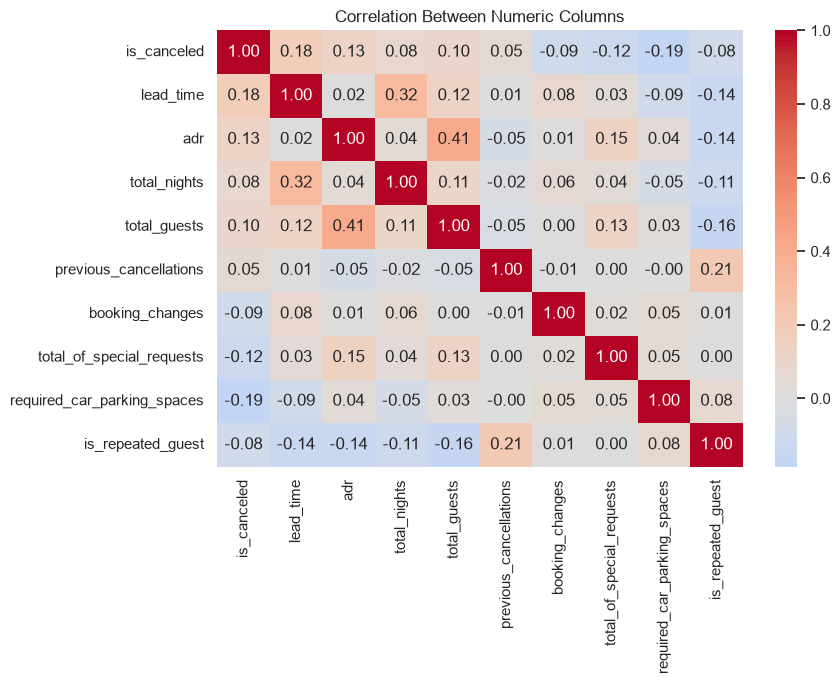

In [19]:
# Step 1: pick the number columns to compare
cols = ["is_canceled", "lead_time", "adr", "total_nights", "total_guests",
        "previous_cancellations", "booking_changes", "total_of_special_requests",
        "required_car_parking_spaces", "is_repeated_guest"]

# Step 2: calculate the correlation table and print it for is_canceled
corr = df[cols].corr()
print(corr["is_canceled"].drop("is_canceled").sort_values().round(2))

# Step 3: draw the heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Between Numeric Columns")

# Step 4: tidy up, save, and show
plt.tight_layout()
plt.savefig(VISUALS_DIR / "10_correlation_heatmap.png")
plt.show()

### Insights

1. **No single factor strongly predicts cancellation.**  
   The strongest correlation is only **0.19**, which is relatively small. This means cancellation depends on **several factors together**, rather than one single number.

   This is why the group comparisons for **hotel, lead time, deposit, and booking channel** are more useful than looking at one correlation number.

2. **Lead time is an important factor.**  
   `lead_time` has a correlation of **+0.18**, which is the strongest among these variables.

   This supports our earlier finding that **guests who book further in advance are more likely to cancel**.

3. **Guests who make special requests cancel less.**  
   Guests with **no special requests** have a **33.5% cancellation rate**, while guests with **3 or more requests** have only a **16.2% cancellation rate**.

   This suggests that guests who make requests are probably **more serious about their stay**. Special requests could therefore be a useful signal for the hotel.

4. **Some variables are related to each other.**  
   - `adr` and `total_guests` have a correlation of **0.41** → more guests are often associated with a higher nightly price.
   - `lead_time` and `total_nights` have a correlation of **0.32** → longer stays are often booked further in advance.

   These relationships are expected, but they remind us that **different factors can overlap**.

### Two Important Warnings

- **Correlation only measures straight-line relationships.**  
  For example, `previous_cancellations` has a correlation of only **0.05**, which looks very weak.

  However, when we compare groups, we see something interesting: guests with **1 previous cancellation have a 76.4% cancellation rate**, based on **1,401 bookings**, while guests with **2 or more** have a rate of around **30%**.

  This shows why we should not rely only on a correlation heatmap. **Group comparisons can reveal patterns that correlation misses.**

- **Correlation does not mean causation.**  
  Parking has a correlation of **-0.19** with cancellations. This does **not** mean that offering parking causes fewer cancellations.

  It may simply mean that guests who need parking are **driving to the hotel and are more committed to their trip**.

### Main takeaway

**Cancellations depend on a combination of factors, not one single variable. Lead time is an important signal, and special requests may indicate that a guest is more committed. However, correlation alone cannot tell us what actually causes cancellations.**